
# 🧠 Sesión: Introducción a Redes Neuronales


## Objetivos de aprendizaje
- Entender qué es una red neuronal artificial y sus componentes básicos (neuronas, capas, activaciones, pérdida, optimización).
- Calcular manualmente un "forward pass" y un ejemplo de **retropropagación** (backprop) simplificada.
- Entrenar un perceptrón/logistic regression para un problema linealmente separable.
- Resolver **XOR** con una red neuronal mínima implementada con `NumPy`.
- Usar librerías "básicas": `NumPy`, `Matplotlib`, `scikit-learn` y una introducción breve a `TensorFlow/Keras`.

> Nota: El contenido está pensado para correr en Google Colab o un entorno local con Python 3.10+.


## 📦 Instalación (si la necesitas)

In [ ]:

# Si estás en Colab puede que ya tengas estas librerías.
# Descomenta si hace falta instalarlas.

# !pip install -q numpy matplotlib scikit-learn tensorflow


## 🧩 ¿Qué es una neurona artificial?

Una **neurona artificial** es la unidad básica de una red neuronal.  
Su propósito es **recibir señales de entrada**, procesarlas mediante una combinación lineal y una **función de activación no lineal**, y producir una salida.

Matemáticamente se define como:

$$
z = \mathbf{w}^\top \mathbf{x} + b
$$
$$
y = \phi(z)
$$

donde:

- $\mathbf{x}$ → vector de entradas (características o señales provenientes de otras neuronas)  
- $\mathbf{w}$ → pesos sinápticos (importancia de cada entrada)  
- $b$ → sesgo o “bias”, que permite ajustar el desplazamiento de la activación  
- $\phi(\cdot)$ → función de activación (por ejemplo: `sigmoid`, `tanh`, `ReLU`)  
- $y$ → salida de la neurona  

![Neurona](https://www.futurespace.es/wp-content/uploads/2021/04/Etimologia-de-la-red-neuronal.jpg)

**Intuición:**  
Cada neurona “aprende” a detectar ciertos patrones o combinaciones de las entradas. Durante el entrenamiento, los pesos y sesgos se ajustan para minimizar un error global medido sobre muchos ejemplos.

---

## 🧠 Red neuronal artificial (RNA)

Una **red neuronal artificial** es un conjunto de neuronas interconectadas, organizadas en **capas**:

1. **Capa de entrada:** recibe las características o variables del problema.  
2. **Capas ocultas:** transforman las representaciones mediante combinaciones no lineales.  
3. **Capa de salida:** produce la predicción o clasificación final.

El flujo de información sigue dos pasos principales:

- **Propagación hacia adelante (Forward Pass):**  
  Las entradas pasan capa a capa hasta obtener la salida $\hat{y}$.  

- **Retropropagación (Backpropagation):**  
  Se calcula el error entre la salida $\hat{y}$ y el valor real $y$, y se actualizan los parámetros mediante **gradiente descendente**.

**Objetivo del entrenamiento:**  
Encontrar los pesos $ \mathbf{W} $ y sesgos $ \mathbf{b} $ que minimicen una **función de pérdida** $ \mathcal{L}(y, \hat{y}) $, como la entropía cruzada o el error cuadrático medio.

---

### 🔍 Analogía intuitiva
> Una red neuronal funciona como un sistema de decisiones en capas:  
> cada capa “aprende” a reconocer estructuras más complejas a partir de patrones simples, tal como el cerebro humano reconoce líneas, formas y finalmente objetos.


## ⚙️ Funciones de activación (definiciones y problemas comunes)

### Escalón simétrico (bipolar step)
La versión “bipolar” del escalón devuelve $-1$ o $1$ (algunas convenciones usan $0$ en $z=0$):

$$
\mathrm{step}_s(z)=
\begin{cases}
+1, & z \ge 0 \\
-1, & z < 0
\end{cases}
$$

**Pros:** extremadamente simple, útil en el perceptrón clásico y en lógica binaria.  
**Contras:** no es diferenciable en $z=0$ y su derivada es $0$ casi en todas partes ⇒ **no hay gradientes** para aprendizaje por descenso de gradiente; además, pequeñas variaciones en $z$ no cambian la salida ⇒ aprendizaje inestable o imposible con backprop.

---

### Sigmoid
$$
\sigma(z)=\frac{1}{1+e^{-z}} \quad\in (0,1), \qquad
\sigma'(z)=\sigma(z)\,(1-\sigma(z))
$$

**Pros:** interpreta salidas como probabilidades; apropiada en la **capa de salida binaria**.  
**Contras:** **no centrada en cero** (promedio positivo), lo que puede ralentizar la convergencia; **saturación** para $|z|$ grandes ⇒ **gradientes que se desvanecen**; sensible al escalado de entradas y pesos.

---

### tanh
$$
\tanh(z)\in(-1,1), \qquad
\frac{d}{dz}\tanh(z)=1-\tanh^2(z)
$$

**Pros:** **centrada en cero**, suele entrenar mejor que sigmoid en capas ocultas.  
**Contras:** también **satura** para \(|z|\) grandes ⇒ **vanishing gradients**; requiere normalización/estandarización de entradas.

---

### ReLU
$$
\mathrm{ReLU}(z)=\max(0,z), \qquad
\mathrm{ReLU}'(z)=
\begin{cases}
0,& z<0\\
1,& z>0
\end{cases}
$$

**Pros:** computacionalmente simple; **gradientes no saturan** en la región positiva; induce **esparsidad**.  
**Contras:** **"Dying ReLU"**: si muchas neuronas quedan en $z<0$, su gradiente es 0 y no se reactivan; **no centrada** y **salida no acotada** (posibles explosiones si no hay normalización); no diferenciable en 0 (se usa subgradiente).

---

### Softmax
$$
\mathrm{softmax}(z_i)=\frac{e^{z_i}}{\sum_{j} e^{z_j}}
$$

**Ventajas:**
- Convierte un vector en una distribución de probabilidad ($\sum_{i} p_i = 1$).
- Útil en la **capa de salida multiclase** con pérdida `categorical_crossentropy`.

**Limitaciones:**
- Puede ser numéricamente inestable (usa `log-sum-exp` para estabilidad).
- Tiende a generar salidas muy "confiadas" (probabilidades extremas).
- No adecuada para capas ocultas, solo para la salida final.

---

### 🧭 Recomendaciones prácticas
| Caso de uso | Activación sugerida | Observaciones |
|--------------|---------------------|----------------|
| Capas ocultas | ReLU / LeakyReLU / GELU | Evitan saturación y aceleran entrenamiento |
| Salida binaria | Sigmoid | Con `binary_crossentropy` |
| Salida multiclase | Softmax | Con `categorical_crossentropy` |
| Modelos antiguos / lógicos | Escalón o tanh | ---

### Softmax
$$
\mathrm{softmax}(z_i)=\frac{e^{z_i}}{\sum_{j} e^{z_j}}
$$

**Ventajas:**
- Convierte un vector en una distribución de probabilidad ($\sum_i p_i = 1$).
- Útil en la **capa de salida multiclase** con pérdida `categorical_crossentropy`.

**Limitaciones:**
- Puede ser numéricamente inestable (usa `log-sum-exp` para estabilidad).
- Tiende a generar salidas muy “confiadas” (probabilidades extremas).
- No adecuada para capas ocultas, solo para la salida final.

---

### 🧭 Recomendaciones prácticas
| Caso de uso | Activación sugerida | Observaciones |
|--------------|---------------------|----------------|
| Capas ocultas | ReLU / LeakyReLU / GELU | Evitan saturación y aceleran entrenamiento |
| Salida binaria | Sigmoid | Con `binary_crossentropy` |
| Salida multiclase | Softmax | Con `categorical_crossentropy` |
| Modelos antiguos / lógicos | Escalón o tanh | No diferenciables o con gradientes débiles|
---

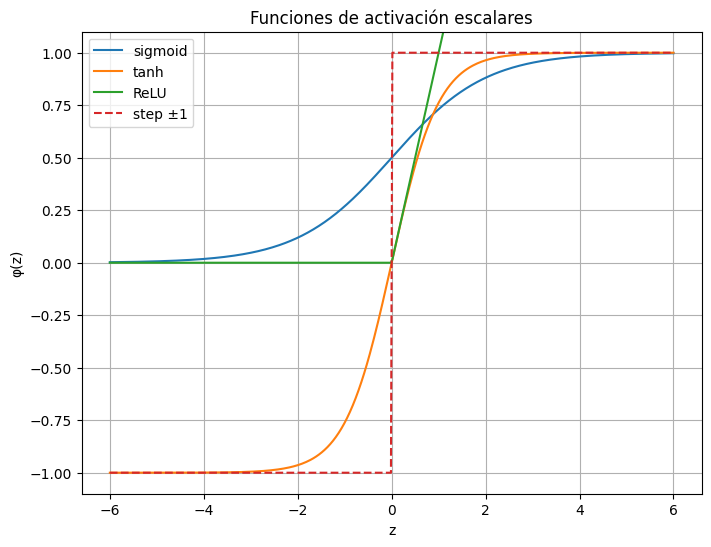

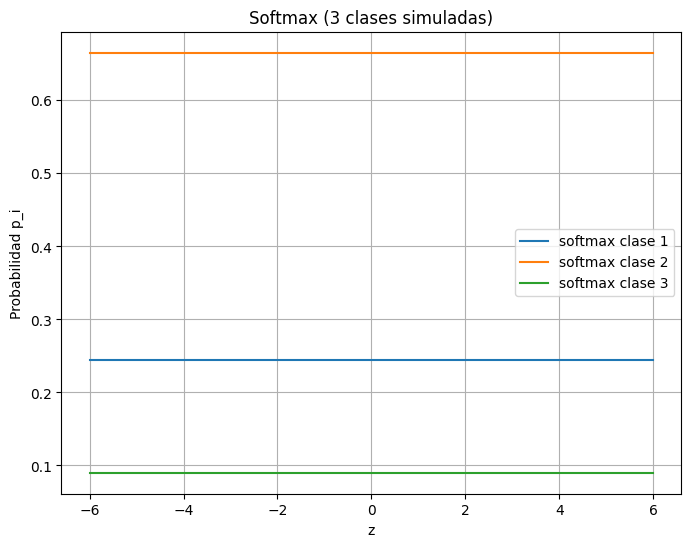

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 400)

# Activaciones básicas
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)
step_sym = np.where(z >= 0, 1.0, -1.0)

# Softmax (en este caso 3 neuronas simuladas)
Z = np.vstack([z, z + 1, z - 1])
softmax = np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)

# Graficar funciones escalares
plt.figure(figsize=(8, 6))
plt.plot(z, sigmoid, label="sigmoid")
plt.plot(z, tanh, label="tanh")
plt.plot(z, relu, label="ReLU")
plt.plot(z, step_sym, "--", label="step ±1")
plt.title("Funciones de activación escalares")
plt.legend()
plt.xlabel("z")
plt.ylabel("φ(z)")
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.show()

# Graficar softmax (vectorial)
plt.figure(figsize=(8, 6))
for i in range(softmax.shape[0]):
    plt.plot(z, softmax[i], label=f"softmax clase {i+1}")
plt.title("Softmax (3 clases simuladas)")
plt.xlabel("z")
plt.ylabel("Probabilidad p_i")
plt.legend()
plt.grid(True)
plt.show()


---

### Leaky ReLU
$$
\text{LeakyReLU}(z)=
\begin{cases}
\alpha z, & z<0 \\
z, & z\ge 0
\end{cases}
$$

con $\alpha \approx 0.01$.  
**Ventajas:** soluciona parcialmente el problema de “neuronas muertas”.  
**Limitaciones:** pendiente negativa pequeña puede generar ruido en aprendizaje.

---

### ELU (Exponential Linear Unit)
$$
\text{ELU}(z)=
\begin{cases}
z, & z>0 \\
\alpha(e^{z}-1), & z\le 0
\end{cases}
$$

**Ventajas:** salida centrada en 0, gradientes más suaves que ReLU.  
**Limitaciones:** requiere cálculo exponencial (ligeramente más costoso).

---

### GELU (Gaussian Error Linear Unit)
$$
\text{GELU}(z)=z \cdot \Phi(z)
$$
donde $\Phi(z)$ es la función de distribución normal estándar.  
**Ventajas:** usada en Transformers (BERT, GPT); combina propiedades suaves de ReLU y probabilidad.  
**Limitaciones:** cálculo más costoso; difícil de interpretar intuitivamente.

---


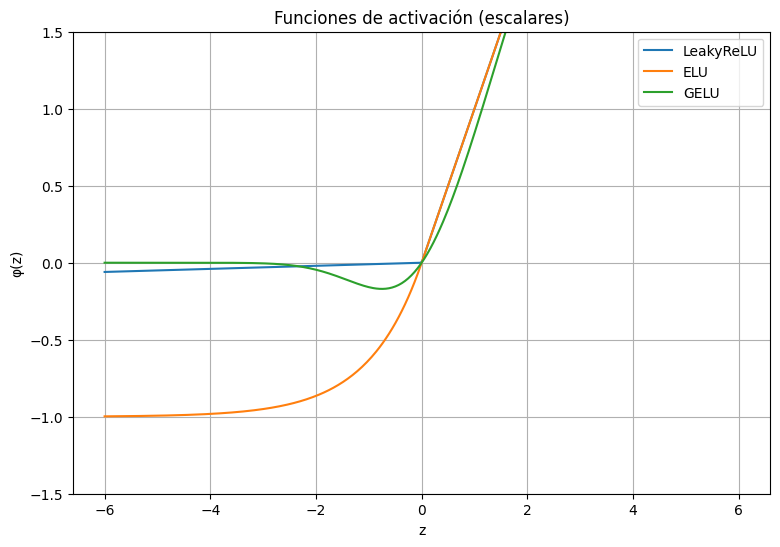

In [ ]:
from scipy.stats import norm

z = np.linspace(-6, 6, 400)

leaky_relu = np.where(z >= 0, z, 0.01*z)
elu = np.where(z >= 0, z, 1.0*(np.exp(z) - 1))
gelu = z * norm.cdf(z)

# Gráfico 1: funciones escalares
plt.figure(figsize=(9, 6))
plt.plot(z, leaky_relu, label="LeakyReLU")
plt.plot(z, elu, label="ELU")
plt.plot(z, gelu, label="GELU")
plt.title("Funciones de activación (escalares)")
plt.xlabel("z")
plt.ylabel("φ(z)")
plt.legend()
plt.grid(True)
plt.ylim(-1.5, 1.5)
plt.show()



## 🚀 Forward Pass (Propagación hacia adelante)

El **forward pass** (propagación hacia adelante) es la fase del entrenamiento en la que una red neuronal **calcula la salida** a partir de una entrada, **utilizando los pesos y sesgos actuales** de cada capa.

En esta etapa **no se actualizan parámetros**; solo se realiza el flujo de datos desde la **entrada → capas ocultas → salida**, aplicando funciones de activación en cada paso.

---

### 🔹 Proceso general

Supongamos una red con una capa oculta:

1. **Entrada:**  
   El vector de entrada es $x \in \mathbb{R}^{n}$.

2. **Primera capa (oculta):**  
   - Cálculo lineal:  
     $z^{[1]} = W^{[1]}x + b^{[1]}$
   - Activación no lineal:  
     $a^{[1]} = \phi(z^{[1]})$

3. **Capa de salida:**  
   - Cálculo lineal:  
     $z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}$
   - Activación final (por ejemplo, `sigmoid` o `softmax`):  
     $a^{[2]} = \phi(z^{[2]}) = \hat{y}$

---

### 🔸 Intuición

Cada capa **transforma las entradas** en representaciones más útiles:
- Los **pesos** $W$ controlan la importancia de cada conexión.
- Los **sesgos** $b$ desplazan la activación.
- Las **funciones de activación** $\phi$ añaden no linealidad para capturar relaciones complejas.

El resultado final $\hat{y}$ es la **predicción del modelo**.

---

### 🧮 Ejemplo esquemático

Para una red de 2-2-1 neuronas:

$$
x = [x_1, x_2]
\Rightarrow
z^{[1]} = W^{[1]}x + b^{[1]} \Rightarrow a^{[1]} = \phi(z^{[1]})
\Rightarrow
z^{[2]} = W^{[2]}a^{[1]} + b^{[2]} \Rightarrow a^{[2]} = \hat{y}
$$

Donde:
- $W^{[1]}$ es una matriz de pesos (2×2),
- $b^{[1]}$ es un vector de sesgos (2×1),
- $\phi$ puede ser `sigmoid`, `tanh` o `ReLU`.

---

### 💡 Resumen

| Etapa | Cálculo | Resultado |
|--------|----------|------------|
| 1️⃣ Capa oculta | $z^{[1]} = W^{[1]}x + b^{[1]}$ | Combinación lineal |
|   | $a^{[1]} = \phi(z^{[1]})$ | Activación no lineal |
| 2️⃣ Capa de salida | $z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}$ | Cálculo final |
|   | $a^{[2]} = \phi(z^{[2]}) = \hat{y}$ | Predicción |

En la siguiente fase (**backward pass** o *retropropagación*), se calcularán los gradientes de la pérdida con respecto a estos parámetros para actualizarlos.

In [ ]:
import numpy as np

def sigmoid(x):
    return 1/(1+np.exp(-x))

# Entrada (x1, x2)
x = np.array([[0.5], [1.0]])  # forma (2,1)

# Pesos y sesgos (elegidos a mano solo para el ejemplo)
W1 = np.array([[1.0, -1.0],
               [0.5,  1.5]])   # (2,2)
b1 = np.array([[0.0],
               [0.0]])         # (2,1)

W2 = np.array([[1.2, -0.7]])   # (1,2)
b2 = np.array([[0.1]])         # (1,1)

# Capa oculta
z1 = W1 @ x + b1
a1 = sigmoid(z1)

# Capa de salida
z2 = W2 @ a1 + b2
a2 = sigmoid(z2)  # probabilidad

z1, a1, z2, a2


(array([[-0.5 ],
        [ 1.75]]),
 array([[0.37754067],
        [0.8519528 ]]),
 array([[-0.04331816]]),
 array([[0.48917215]]))

## 🔁 Backward Pass (Retropropagación)

El **backward pass** o **retropropagación** es la fase en la que la red neuronal **aprende**, es decir, **ajusta sus pesos y sesgos** para minimizar el error entre la salida predicha $\hat{y}$ y la salida real $y$.

Durante esta etapa se aplican las **reglas del cálculo diferencial (regla de la cadena)** para propagar los gradientes desde la salida hacia las capas anteriores.

---

### 🔹 Objetivo

Minimizar una función de pérdida $\mathcal{L}(y, \hat{y})$, por ejemplo:

- Para clasificación binaria con `sigmoid`:  
  $\mathcal{L}(y, \hat{y}) = -\,[\,y\log(\hat{y}) + (1-y)\log(1-\hat{y})\,]$

- Para regresión (MSE):  
  $\mathcal{L}(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2$

Para nuestro ejemplo consideraremos la primera opción

---

### 🔸 Propagación de gradientes

Para comprender el **backward pass**, es clave entender **de dónde proviene cada gradiente** y **cómo se calcula** mediante la **regla de la cadena**.

Recordemos que el objetivo es minimizar la **función de pérdida** $\mathcal{L}(y, \hat{y})$, donde:

- $y$ → etiqueta real  
- $\hat{y}$ → salida de la red (predicción)  
- los pesos y sesgos ($W$, $b$) son los parámetros que queremos ajustar.

---

### 🔹 1. Partimos del forward pass

En una red 2–2–1:

- Capa oculta:
  - $z^{[1]} = W^{[1]}x + b^{[1]}$
  - $a^{[1]} = \phi(z^{[1]})$
- Capa de salida:
  - $z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}$
  - $a^{[2]} = \phi(z^{[2]}) = \hat{y}$

La pérdida para un solo ejemplo (clasificación binaria con sigmoid) es:

$$
\mathcal{L}(y, \hat{y}) = - \big[\, y\log(\hat{y}) + (1-y)\log(1-\hat{y}) \,\big]
$$

---

### 🔸 2. Gradiente en la salida

Queremos saber **cómo cambia la pérdida si cambia la salida** $\hat{y}$.

$$
\frac{\partial \mathcal{L}}{\partial \hat{y}} = - \frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}
$$

Como $\hat{y} = \phi(z^{[2]})$, aplicamos la regla de la cadena:

$$
\frac{\partial \mathcal{L}}{\partial z^{[2]}} =
\frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot
\frac{\partial \hat{y}}{\partial z^{[2]}}
$$

Para la sigmoid:
$\frac{\partial \hat{y}}{\partial z^{[2]}} = \hat{y}(1-\hat{y})$

Simplificando (y tras cancelar términos algebraicamente), se obtiene un resultado elegante:

$$
\frac{\partial \mathcal{L}}{\partial z^{[2]}} = \hat{y} - y
$$

👉 **Interpretación:** el error en la salida es simplemente la diferencia entre la predicción y la etiqueta.

---

### 🔹 3. Gradientes de la capa de salida

Sabemos que:
$z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}$

Aplicamos derivadas parciales respecto a cada parámetro:

- Con respecto a los pesos:
  $$
  \frac{\partial \mathcal{L}}{\partial W^{[2]}} =
  \frac{\partial \mathcal{L}}{\partial z^{[2]}} \cdot
  \frac{\partial z^{[2]}}{\partial W^{[2]}} =
  (\hat{y} - y)\,{a^{[1]}}^T
  $$

- Con respecto al sesgo:
  $$
  \frac{\partial \mathcal{L}}{\partial b^{[2]}} = \hat{y} - y
  $$

📘 *Cada peso se ajusta proporcionalmente al error de salida y a la activación de la neurona anterior.*

---

### 🔸 4. Gradiente hacia la capa oculta

El gradiente debe seguir viajando hacia atrás para actualizar $W^{[1]}$ y $b^{[1]}$.

Aplicamos la regla de la cadena:

1. **Cómo cambia la pérdida con respecto a la activación anterior:**
   $$
   \frac{\partial \mathcal{L}}{\partial a^{[1]}} =
   (W^{[2]})^T \frac{\partial \mathcal{L}}{\partial z^{[2]}}
   $$

   → indica cómo el error de la salida “afecta” cada neurona en la capa oculta.

2. **Cómo cambia respecto al valor previo a la activación:**
   $$
   \frac{\partial \mathcal{L}}{\partial z^{[1]}} =
   \frac{\partial \mathcal{L}}{\partial a^{[1]}} \odot \phi'(z^{[1]})
   $$

   → el símbolo $\odot$ denota multiplicación elemento a elemento (*Hadamard product*).  
   Aquí usamos la derivada de la función de activación $\phi$ (por ejemplo, $\sigma'(z)=\sigma(z)(1-\sigma(z))$).

---

### 🔹 5. Gradientes de la capa oculta

De nuevo, como $z^{[1]} = W^{[1]}x + b^{[1]}$, tenemos:

- Para los pesos:
  $$
  \frac{\partial \mathcal{L}}{\partial W^{[1]}} =
  \frac{\partial \mathcal{L}}{\partial z^{[1]}}\,x^T
  $$

- Para los sesgos:
  $$
  \frac{\partial \mathcal{L}}{\partial b^{[1]}} =
  \frac{\partial \mathcal{L}}{\partial z^{[1]}}
  $$

---

### 🔸 6. Conclusión

Cada gradiente proviene de **aplicar la regla de la cadena** sobre la composición de funciones del forward pass:

$$
x \xrightarrow{W^{[1]}, b^{[1]}} z^{[1]} \xrightarrow{\phi} a^{[1]}
\xrightarrow{W^{[2]}, b^{[2]}} z^{[2]} \xrightarrow{\phi} \hat{y}
\xrightarrow{\mathcal{L}} \text{pérdida}
$$

- La **pérdida** genera el error inicial.  
- Ese error se **propaga hacia atrás** capa a capa.  
- Cada peso se ajusta según **cuánto contribuyó al error final**.

En resumen, el backward pass no es magia:
es **aplicar la regla de la cadena una y otra vez** para distribuir la responsabilidad del error a todos los parámetros de la red.

---

### 🔹 Actualización de parámetros

Cada parámetro se actualiza con **gradiente descendente**:

$$
W \leftarrow W - \eta \,\frac{\partial \mathcal{L}}{\partial W}, \quad
b \leftarrow b - \eta \,\frac{\partial \mathcal{L}}{\partial b}
$$

donde $\eta$ es la **tasa de aprendizaje** (*learning rate*).

---

### 💡 Intuición

- El **forward pass** calcula las predicciones.  
- El **backward pass** mide el error y ajusta los parámetros en la dirección que **reduce la pérdida**.  
- Este proceso se repite durante muchas épocas hasta que la red **aprende una representación útil** de los datos.

---

| Etapa | Dirección | Propósito |
|--------|------------|------------|
| Forward pass | Entrada → Salida | Generar predicciones |
| Backward pass | Salida → Entrada | Calcular gradientes y ajustar parámetros |

## 🔸 ¿Por qué se usa el producto de Hadamard en el Backward Pass?

Durante el **backward pass**, cuando calculamos los gradientes que se propagan hacia una capa anterior, necesitamos combinar dos tipos de información:

1. **El gradiente que viene de la capa siguiente**,  
   es decir, cuánto cambia la pérdida $\mathcal{L}$ si cambian las salidas de la capa actual.  
   Matemáticamente: $\frac{\partial \mathcal{L}}{\partial a^{[l]}}$

2. **La derivada de la función de activación** de esa capa,  
   que nos indica cómo cambia la activación respecto a su entrada lineal $z^{[l]}$.  
   Matemáticamente: $\frac{\partial a^{[l]}}{\partial z^{[l]}} = \phi'(z^{[l]})$

---

### 🔹 Aplicando la regla de la cadena

Cuando queremos saber cómo cambia la pérdida respecto a los valores $z^{[l]}$, usamos:

$$
\frac{\partial \mathcal{L}}{\partial z^{[l]}}
= \frac{\partial \mathcal{L}}{\partial a^{[l]}}
\cdot
\frac{\partial a^{[l]}}{\partial z^{[l]}}
$$

El problema es que **ambos términos son vectores** (uno por cada neurona de la capa).  
Por ejemplo, si una capa tiene 3 neuronas:

- $\frac{\partial \mathcal{L}}{\partial a^{[l]}} = [g_1, g_2, g_3]$  
- $\phi'(z^{[l]}) = [\phi'_1, \phi'_2, \phi'_3]$

La derivada de $\mathcal{L}$ respecto a cada $z_i$ debe tomar el gradiente correspondiente $g_i$ multiplicado por la derivada de su propia activación $\phi'_i$.

---

### ⚙️ Producto de Hadamard (multiplicación elemento a elemento)

Por eso usamos el **producto de Hadamard** (denotado por $\odot$):

$$
\frac{\partial \mathcal{L}}{\partial z^{[l]}}
= \frac{\partial \mathcal{L}}{\partial a^{[l]}} \odot \phi'(z^{[l]})
$$

que equivale a:

$$
\begin{bmatrix}
g_1 \\ g_2 \\ g_3
\end{bmatrix}
\odot
\begin{bmatrix}
\phi'_1 \\ \phi'_2 \\ \phi'_3
\end{bmatrix}
=
\begin{bmatrix}
g_1 \cdot \phi'_1 \\
g_2 \cdot \phi'_2 \\
g_3 \cdot \phi'_3
\end{bmatrix}
$$

Cada neurona **se actualiza de manera independiente**, multiplicando su propio gradiente por su propia derivada local.

---

### 💡 Intuición

- Si una neurona está **saturada** (por ejemplo, con `sigmoid` cuando $|z|$ es grande), su $\phi'(z)$ es casi 0.  
  → El producto de Hadamard hace que el gradiente que le llega también sea casi 0.  
  → Esa neurona **aprende más lento o se “apaga”**.

- Si la activación tiene una derivada grande (por ejemplo, en `ReLU` para $z>0$),  
  el gradiente se transmite **sin atenuación**.

---

### 🧩 En resumen

| Concepto | Operación | Motivo |
|-----------|------------|--------|
| Propagación de error hacia atrás | $\frac{\partial \mathcal{L}}{\partial z^{[l]}} = \frac{\partial \mathcal{L}}{\partial a^{[l]}} \odot \phi'(z^{[l]})$ | Aplica la regla de la cadena neurona a neurona |
| Uso del producto de Hadamard | Multiplicación elemento a elemento | Cada neurona tiene su propio gradiente y derivada |
| Consecuencia | Evita mezclar gradientes entre neuronas | Permite aprendizaje independiente en cada unidad |

El producto de Hadamard es, por tanto, **la forma matricial de aplicar la regla de la cadena componente a componente**, asegurando que **cada neurona propague su propio error local** de manera correcta.


## 🎯 ¿Por qué se usa la función de pérdida de entropía cruzada con la Sigmoid?

Cuando se usa una **función de activación Sigmoid** en la salida de una red neuronal, el objetivo es **modelar una probabilidad**.

Recordemos que:
$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$
produce un valor en el rango $(0,1)$, que puede interpretarse como:
- $\hat{y} =$ probabilidad de que la clase sea **1**,  
- $(1 - \hat{y}) =$ probabilidad de que la clase sea **0**.

Por tanto, el problema se convierte en una **clasificación binaria probabilística**, y la pérdida debe **medir qué tan buena es esa probabilidad predicha**.

---

### 🔹 La pérdida de entropía cruzada (Binary Cross-Entropy)

Se define como:

$$
\mathcal{L}(y, \hat{y}) = - \big[\, y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \,\big]
$$

donde:
- $y \in \{0,1\}$ es la etiqueta real,  
- $\hat{y}$ es la probabilidad predicha por la red.

Esta función **castiga fuertemente las predicciones seguras pero incorrectas**, y **recompensa** las predicciones que asignan alta probabilidad a la clase correcta.

---

### 🔸 Intuición probabilística

Esta pérdida proviene del **modelo de máxima verosimilitud** (Maximum Likelihood Estimation).

Si asumimos que las etiquetas siguen una distribución **Bernoulli**:

$$
P(y | x; W) = \hat{y}^y (1 - \hat{y})^{(1-y)}
$$

entonces el logaritmo de la verosimilitud es:

$$
\log P(y | x; W) = y \log(\hat{y}) + (1 - y)\log(1 - \hat{y})
$$

Queremos **maximizar** esta verosimilitud (que la red asigne alta probabilidad a la clase correcta),  
lo que equivale a **minimizar la pérdida negativa**:

$$
\mathcal{L} = - \log P(y | x; W)
$$

Es decir, **la entropía cruzada es la versión negativa del log-likelihood**.

---

### 🔹 Propiedades útiles

1. **Alinea bien con la salida Sigmoid:**  
   - La Sigmoid entrega probabilidades.  
   - La entropía cruzada mide qué tan “lejos” están de las etiquetas reales (0 o 1).

2. **Derivada simple para backpropagation:**  
   Al combinar `Sigmoid` con `Cross-Entropy`, la derivada del error en la salida se simplifica:
   $$
   \frac{\partial \mathcal{L}}{\partial z} = \hat{y} - y
   $$
   Esto evita los problemas de *vanishing gradients* que aparecen si se usa MSE con Sigmoid.

3. **Penaliza fuertemente la confianza incorrecta:**  
   - Si el modelo predice $\hat{y}=0.99$ pero $y=0$,  
     la pérdida será grande ($\mathcal{L}\approx 4.6$).  
   - Si el modelo predice $\hat{y}=0.51$ y $y=0$,  
     la pérdida será pequeña ($\mathcal{L}\approx 0.7$).  

   👉 Esto incentiva al modelo a ser “confiado” **solo cuando realmente acierta**.

---

### 💡 En resumen

| Concepto | Explicación |
|-----------|-------------|
| Tipo de salida | Probabilidad (Sigmoid) |
| Distribución asumida | Bernoulli |
| Pérdida derivada | Entropía cruzada binaria |
| Propósito | Maximizar la ve


### 🧮 Ejemplo: Forward + Backward pass en una red 2-2-1 (sigmoid)

In [ ]:
# ---------- Configuración inicial ----------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(a):
    return a * (1 - a)

# Datos de entrada (2 características, 1 muestra)
x = np.array([[0.5], [1.0]])
y = np.array([[1.0]])  # salida real

# Pesos y sesgos iniciales
W1 = np.array([[1.0, -1.0],
               [0.5,  1.5]])
b1 = np.zeros((2, 1))

W2 = np.array([[1.2, -0.7]])
b2 = np.array([[0.1]])

# ---------- FORWARD PASS ----------
z1 = W1 @ x + b1
a1 = sigmoid(z1)

z2 = W2 @ a1 + b2
a2 = sigmoid(z2)   # salida predicha (ŷ)

print("Salida predicha (ŷ):", a2)

# ---------- BACKWARD PASS ----------
# Gradiente de la pérdida (Binary Cross-Entropy simplificada)
dz2 = a2 - y                         # (1,1)
dW2 = dz2 @ a1.T                     # (1,2)
db2 = dz2                            # (1,1)

# Gradientes hacia la capa oculta
da1 = W2.T @ dz2                     # (2,1)
dz1 = da1 * sigmoid_deriv(a1)        # (2,1)
dW1 = dz1 @ x.T                      # (2,2)
db1 = dz1                            # (2,1)

# ---------- Actualización de parámetros ----------
eta = 0.1  # tasa de aprendizaje
W2 -= eta * dW2
b2 -= eta * db2
W1 -= eta * dW1
b1 -= eta * db1

print("\nGradientes:")
print("dW2:", dW2)
print("dW1:", dW1)
print("\nPesos actualizados:")
print("W2:", W2)
print("W1:", W1)

Salida predicha (ŷ): [[0.48917215]]

Gradientes:
dW2: [[-0.19285829 -0.43520122]]
dW1: [[-0.07202786 -0.14405573]
 [ 0.02255061  0.04510122]]

Pesos actualizados:
W2: [[ 1.21928583 -0.65647988]]
W1: [[ 1.00720279 -0.98559443]
 [ 0.49774494  1.49548988]]



## 5) Perceptrón / Regresión logística con `scikit-learn`
Entrenamos un clasificador lineal para un dataset fácilmente separable.


In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1, class_sep=2.0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)

perc = Perceptron()
perc.fit(X_train, y_train)
pred_pe = perc.predict(X_test)

print("Accuracy LogisticRegression:", accuracy_score(y_test, pred_lr))
print("Accuracy Perceptron:", accuracy_score(y_test, pred_pe))
print("\nReporte (LogReg):\n", classification_report(y_test, pred_lr))
print("\nReporte (Perceptron):\n", classification_report(y_test, pred_pe))

Accuracy LogisticRegression: 0.96
Accuracy Perceptron: 0.944

Reporte (LogReg):
               precision    recall  f1-score   support

           0       0.94      0.98      0.96        63
           1       0.98      0.94      0.96        62

    accuracy                           0.96       125
   macro avg       0.96      0.96      0.96       125
weighted avg       0.96      0.96      0.96       125


Reporte (Perceptron):
               precision    recall  f1-score   support

           0       0.94      0.95      0.94        63
           1       0.95      0.94      0.94        62

    accuracy                           0.94       125
   macro avg       0.94      0.94      0.94       125
weighted avg       0.94      0.94      0.94       125



# ❌🔁 El problema XOR (Exclusive OR)

## 🧩 Definición lógica

**XOR** significa *“Exclusive OR”* (O exclusiva).  
Es una operación lógica binaria que devuelve **1 solo si una de las dos entradas es 1, pero no ambas**.

| x₁ | x₂ | XOR(x₁, x₂) |
|----|----|-------------|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

Matemáticamente, puede expresarse como:

$$
\text{XOR}(x_1, x_2) = (x_1 \land \neg x_2) \lor (\neg x_1 \land x_2)
$$

o, de forma algebraica (en $\{0,1\}$):

$$
y = x_1 + x_2 - 2x_1x_2
$$

---

### 📊 Representación geométrica

Si graficamos los puntos $(x_1, x_2)$ y sus salidas $y$:

| x₁ | x₂ | y | Posición en el plano |
|----|----|---|-----------------------|
| 0 | 0 | 0 | abajo-izquierda |
| 0 | 1 | 1 | arriba-izquierda |
| 1 | 0 | 1 | abajo-derecha |
| 1 | 1 | 0 | arriba-derecha |

Visualmente, los puntos con salida 1 están **en diagonal opuesta** (arriba-izquierda y abajo-derecha)


No existe una **línea recta** (hiperplano lineal) que separe perfectamente las clases 0 y 1.

---

### ⚙️ Implicación matemática

El **perceptrón simple** (una red neuronal sin capas ocultas) solo puede resolver **problemas linealmente separables**, es decir, aquellos en los que una frontera lineal puede separar las clases.

En el caso XOR:

- Las clases no son separables por una recta.  
- No existe ningún vector de pesos $W$ ni sesgo $b$ que satisfaga:
  $$
  y = \text{step}(W^T x + b)
  $$
  para todos los puntos de la tabla XOR.

Por tanto, un perceptrón simple **no puede aprender XOR**.

---

### 🧠 Solución: Redes neuronales multicapa

Cuando añadimos una **capa oculta con funciones de activación no lineales** (por ejemplo `sigmoid` o `tanh`), la red puede **aprender combinaciones no lineales de las entradas**.

Esto permite crear **fronteras de decisión no lineales**, por ejemplo:

$$
\begin{align*}
z^{[1]} &= W^{[1]}x + b^{[1]} \\
a^{[1]} &= \phi(z^{[1]}) \\
\hat{y} &= \sigma(W^{[2]}a^{[1]} + b^{[2]})
\end{align*}
$$

Con una capa oculta de solo **dos neuronas**, la red puede **recrear la lógica de XOR** dividiendo el plano en regiones que luego se combinan.

---

### 🔍 Intuición visual

- Una neurona puede aprender una **frontera lineal** (por ejemplo, $x_1 > 0.5$).  
- Otra neurona puede aprender una **frontera perpendicular** (por ejemplo, $x_2 > 0.5$).  
- La capa de salida combina esas activaciones para generar una frontera **no lineal** que representa XOR.

---

### 📚 Importancia histórica

- En 1969, **Minsky y Papert** demostraron que el perceptrón no podía resolver XOR.  
  👉 Esto llevó a una “crisis” en el campo de las redes neuronales por más de una década.  

- En los años 80, con la **retropropagación (backpropagation)** y la idea de **capas ocultas**, se demostró que las redes **multicapa** podían aprender XOR.  
  👉 Esto marcó el **renacimiento del aprendizaje profundo**.

---

### 💡 En resumen

| Concepto | Explicación |
|-----------|-------------|
| XOR | Función lógica no lineal (1 si las entradas son distintas) |
| Separabilidad | No linealmente separable |
| Limitación del perceptrón | No puede resolver XOR |
| Solución | Red neuronal con al menos una capa oculta |
| Importancia | Caso clásico que motivó el uso de redes profundas |

En síntesis, **XOR es el primer ejemplo que muestra el poder de la no linealidad y las capas ocultas**.  
Resolverlo fue el paso que dio origen al **aprendizaje profundo moderno**.







## XOR con `NumPy` (red 2-2-1)
XOR no es linealmente separable ⇒ un perceptrón de una sola capa **no** lo aprende.  
Entrenamos una red minimalista 2→2→1 con sigmoid y descenso de gradiente.


In [ ]:
import numpy as np

# Datos XOR
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)

rng = np.random.default_rng(0)
W1 = rng.normal(scale=0.5, size=(2,2))
b1 = np.zeros((2,1))
W2 = rng.normal(scale=0.5, size=(1,2))
b2 = np.zeros((1,1))

def sigmoid(x): return 1/(1+np.exp(-x))
def sigmoid_deriv(a): return a*(1-a)  # asumiendo a = sigmoid(z)

lr = 0.5
epochs = 5000

losses = []
for ep in range(epochs):
    # forward
    Z1 = X @ W1.T + b1.T      # (4,2)
    A1 = sigmoid(Z1)          # (4,2)
    Z2 = A1 @ W2.T + b2.T     # (4,1)
    A2 = sigmoid(Z2)          # (4,1)

    # loss BCE
    eps = 1e-8
    L = - (y*np.log(A2+eps) + (1-y)*np.log(1-A2+eps)).mean()
    losses.append(L)

    # backprop (sigmoid + BCE: dZ2 = A2 - y)
    dZ2 = (A2 - y) / X.shape[0]      # promedio
    dW2 = dZ2.T @ A1                 # (1,2)
    db2 = dZ2.sum(axis=0, keepdims=True)  # (1,1)

    dA1 = dZ2 @ W2                   # (4,2)
    dZ1 = dA1 * sigmoid_deriv(A1)    # (4,2)
    dW1 = dZ1.T @ X                  # (2,2)
    db1 = dZ1.sum(axis=0, keepdims=True).T  # (2,1)

    # update
    W2 -= lr * dW2
    b2 -= lr * db2.T
    W1 -= lr * dW1
    b1 -= lr * db1

print("Pérdida final:", losses[-1])
print("Predicciones:")
print(np.round(A2, 3))


Pérdida final: 0.007614476768135962
Predicciones:
[[0.009]
 [0.993]
 [0.993]
 [0.007]]


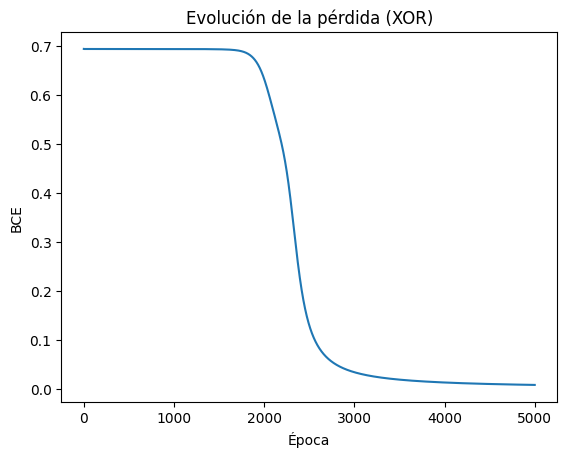

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.title("Evolución de la pérdida (XOR)")
plt.xlabel("Época")
plt.ylabel("BCE")
plt.show()



## 💣 Clasificación no lineal con `MLPClassifier` (scikit-learn)
Usaremos `make_moons` y una MLP con una capa oculta. Visualizaremos la frontera de decisión.


In [ ]:
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
clf = MLPClassifier(hidden_layer_sizes=(8,), activation='tanh', max_iter=2000, random_state=42)
# hidden_layer_sizes=(8,) 1 capa con 8 neuronas
clf.fit(X, y)

MLPClassifier(activation='tanh', hidden_layer_sizes=(8,), max_iter=2000,
              random_state=42)

In [ ]:
# Malla para frontera de decisión
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
    np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid).reshape(xx.shape)

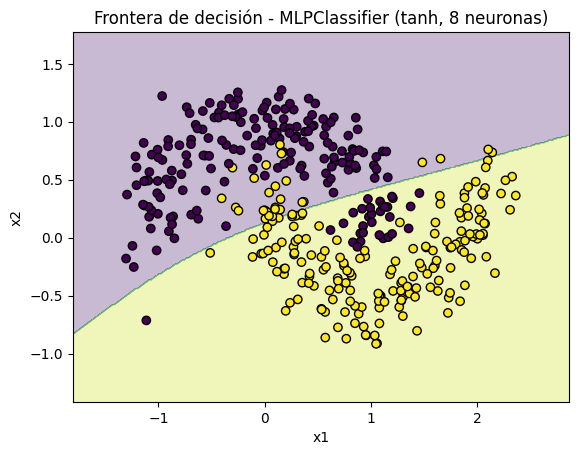

In [ ]:
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
plt.title("Frontera de decisión - MLPClassifier (tanh, 8 neuronas)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [ ]:
clf_s = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', max_iter=2000, random_state=42)
clf_s.fit(X, y)
# 'tanh', 'identity', 'relu', 'logistic'

MLPClassifier(hidden_layer_sizes=(8,), max_iter=2000, random_state=42)

In [ ]:
Z = clf_s.predict(grid).reshape(xx.shape)

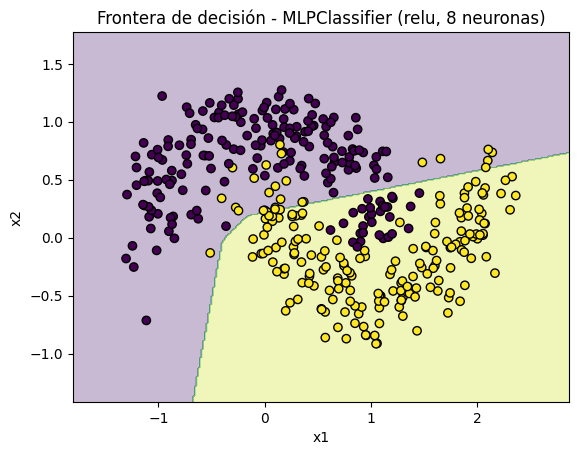

In [ ]:
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
plt.title("Frontera de decisión - MLPClassifier (relu, 8 neuronas)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

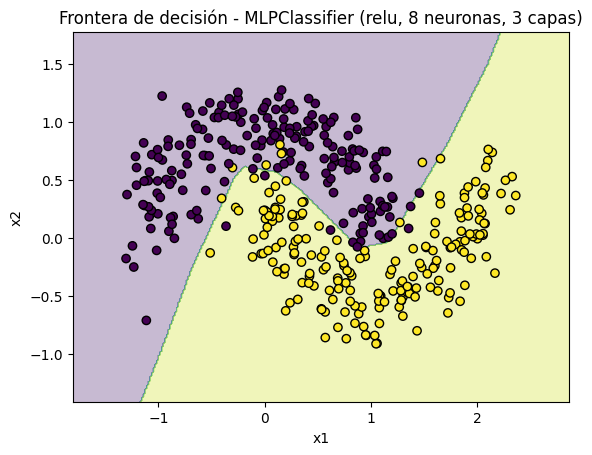

In [ ]:
clf_s = MLPClassifier(hidden_layer_sizes=(8,3), activation='relu', max_iter=2000, random_state=42)
clf_s.fit(X, y)
Z = clf_s.predict(grid).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
plt.title("Frontera de decisión - MLPClassifier (relu, 8 neuronas, 3 capas)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


# Introducción breve a `TensorFlow/Keras`
Keras es una API de alto nivel dentro de **TensorFlow** que permite crear, entrenar y evaluar redes neuronales de manera sencilla y estructurada.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

In [ ]:
# Datos sintéticos
X, y = make_classification(n_samples=1000, n_features=8, n_informative=6, random_state=42)
y = y.astype(np.float32)

# División
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
X.shape[1]

8

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(X.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32, verbose=0)

print("Evaluación en validación:", model.evaluate(X_val, y_val, verbose=0))

Evaluación en validación: [0.3380317986011505, 0.8650000095367432]


In [ ]:
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']

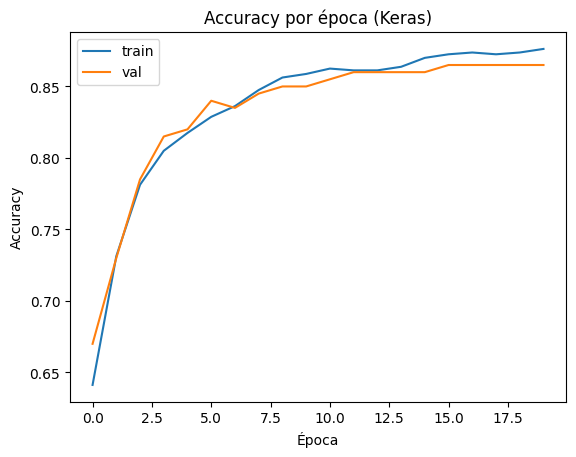

In [ ]:
plt.figure()
plt.plot(acc, label='train')
plt.plot(val_acc, label='val')
plt.title("Accuracy por época (Keras)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 🔹 `Sequential`: el modelo más simple

`Sequential` define un modelo **linealmente apilado**: las capas se ejecutan **una después de otra**.  
Es ideal cuando **cada capa tiene una sola entrada y una sola salida**, sin bifurcaciones ni conexiones complejas.

### Alternativa
```python
inputs = keras.Input(shape=(X.shape[1],))
x = layers.Dense(32, activation='relu')(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

```

## 🪶 Capa de entrada

`layers.Input(shape=(n_features,))`
Define explícitamente la forma del tensor de entrada.
Usualmente es la primera capa en modelos Sequential o Functional.

## 🧠 Capas densas (fully connected)

`layers.Dense(units, activation=...)`

Conecta todas las neuronas de la capa anterior con las de la actual.

## 💧 Dropout

`layers.Dropout(rate)`

Desactiva aleatoriamente una fracción de neuronas durante el entrenamiento para prevenir overfitting.

Ejemplo: layers.Dropout(0.5) desactiva el 50% de las neuronas.

## 📉 Flatten

`layers.Flatten()`
Convierte una entrada multidimensional (p. ej. una imagen 28×28) en un vector 1D para conectarla con capas densas.

Ejemplo:
Entrada (28×28) → Flatten() → (784,)

## 🧩 Convolucionales (para imágenes)

`layers.Conv2D(filters, kernel_size, activation=...)`

Extrae características espaciales de una imagen usando filtros deslizantes.

Ejemplo: layers.Conv2D(32, (3,3), activation='relu')

A menudo se combinan con:

`layers.MaxPooling2D(pool_size=(2,2)) (reducción espacial)`

`layers.BatchNormalization() (normalización de activaciones)`

## ⏱️ Recurrentes (para secuencias y texto)

`layers.SimpleRNN(units)`

`layers.LSTM(units)`

`layers.GRU(units)`

Estas capas mantienen memoria temporal y son útiles en tareas como series de tiempo, texto o audio.

## 🎛️ Normalización y regularización

`layers.BatchNormalization()` → estabiliza y acelera el entrenamiento.

`layers.LayerNormalization()` → versión independiente de la dimensión del lote (batch).

`layers.ActivityRegularization(l1=..., l2=...)` → penaliza activaciones grandes.



| Elemento | Función | Ejemplo |
|-----------|----------|----------|
| **Sequential** | Modelo secuencial lineal (las capas se apilan una tras otra) | `keras.Sequential([...])` |
| **Functional API** | Modelos con múltiples entradas/salidas o ramificaciones | `keras.Model(inputs, outputs)` |
| **Subclassing API** | Modelos definidos como clases personalizadas, con lógica propia | `class MyModel(keras.Model)` |
| **Dense** | Capa totalmente conectada (todas las neuronas se conectan con las siguientes) | `layers.Dense(16, activation='relu')` |
| **Dropout** | Regularización: apaga aleatoriamente neuronas durante el entrenamiento | `layers.Dropout(0.3)` |
| **Conv2D** | Capa convolucional: extrae características espaciales de imágenes | `layers.Conv2D(32, (3,3), activation='relu')` |
| **MaxPooling2D** | Reduce la dimensionalidad conservando la información más relevante | `layers.MaxPooling2D(pool_size=(2,2))` |
| **Flatten** | Convierte una entrada multidimensional en un vector 1D | `layers.Flatten()` |
| **LSTM / GRU / SimpleRNN** | Capas recurrentes: procesan secuencias (texto, series de tiempo) | `layers.LSTM(64)` |
| **BatchNormalization** | Normaliza las activaciones, estabilizando y acelerando el entrenamiento | `layers.BatchNormalization()` |
| **Activation** | Aplica una función de activación específica a las salidas | `layers.Activation('tanh')` |
| **Input** | Define explícitamente la forma de entrada al modelo | `layers.Input(shape=(n_features,))` |
| **Output (Dense final)** | Genera la salida del modelo según la tarea (sigmoid, softmax, etc.) | `layers.Dense(1, activation='sigmoid')` |



## ⚙️ Optimizadores en Keras: cómo aprenden las redes neuronales

Durante el **entrenamiento**, las redes neuronales ajustan sus parámetros (pesos y sesgos) para **minimizar la función de pérdida**.  
Los **optimizadores** definen **cómo se actualizan esos parámetros** a partir de los gradientes calculados en el *backward pass*.

---

### 🔹 Descenso de gradiente básico

Todos los optimizadores derivan del mismo principio:

$$
\theta_{t+1} = \theta_t - \eta \, \nabla_\theta \mathcal{L}(\theta_t)
$$

donde:

- $\theta$ → parámetros del modelo (pesos y sesgos),  
- $\eta$ → tasa de aprendizaje (*learning rate*),  
- $\nabla_\theta \mathcal{L}$ → gradiente de la pérdida respecto a los parámetros.

Este método puede ser lento o inestable, por lo que surgen variantes más avanzadas.

---

### 🔸 1. SGD — *Stochastic Gradient Descent*

Actualiza los parámetros en la dirección opuesta al gradiente promedio de un minibatch.

$$
\theta_{t+1} = \theta_t - \eta \, \nabla_\theta \mathcal{L}_t
$$

**Ventajas:** simple y eficiente.  
**Limitaciones:** sensible a gradientes oscilantes; puede atascarse en mínimos locales.

Ejemplo en Keras: `keras.optimizers.SGD(learning_rate=0.01)`

---

### 🔸 2. SGD con Momentum

Agrega una “inercia” al gradiente, acumulando parte del movimiento anterior:

$$
v_t = \beta v_{t-1} + (1 - \beta)\,\nabla_\theta \mathcal{L}_t
$$
$$
\theta_{t+1} = \theta_t - \eta v_t
$$

donde $\beta$ (≈ 0.9) controla cuánto del gradiente previo se conserva.

**Ventajas:** acelera la convergencia y suaviza oscilaciones.  
**Limitaciones:** requiere ajustar $\beta$.

Ejemplo en Keras: `keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)`

---

### 🔸 3. Adagrad — *Adaptive Gradient Algorithm*

Ajusta automáticamente el *learning rate* de cada parámetro, según la magnitud acumulada de sus gradientes.

$$
G_t = G_{t-1} + (\nabla_\theta \mathcal{L}_t)^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \, \nabla_\theta \mathcal{L}_t
$$

**Ventajas:** adapta la tasa de aprendizaje por parámetro.  
**Limitaciones:** la tasa de aprendizaje puede volverse demasiado pequeña con el tiempo.

Ejemplo en Keras: `keras.optimizers.Adagrad(learning_rate=0.01)`

---

### 🔸 4. RMSprop — *Root Mean Square Propagation*

Suaviza la acumulación infinita de Adagrad usando una media móvil exponencial:

$$
E[g^2]_t = \rho E[g^2]_{t-1} + (1 - \rho)(\nabla_\theta \mathcal{L}_t)^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \, \nabla_\theta \mathcal{L}_t
$$

**Ventajas:** mantiene la adaptabilidad sin reducir demasiado $\eta$.  
**Limitaciones:** sensible al valor de $\rho$ (típicamente 0.9).

Ejemplo en Keras: `keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)`

---

### 🔸 5. Adam — *Adaptive Moment Estimation*

Combina **Momentum** y **RMSprop**, calculando promedios móviles de gradientes y sus cuadrados.

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)\nabla_\theta \mathcal{L}_t
$$
$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2)(\nabla_\theta \mathcal{L}_t)^2
$$
$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$
$$
\theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

**Ventajas:**  
- Rápida convergencia.  
- Menor sensibilidad al *learning rate*.  
- Buen desempeño general.

**Limitaciones:**  
- Puede converger a mínimos menos generalizables.  
- A veces requiere *decay* o ajuste de tasa de aprendizaje.

Ejemplo en Keras: `keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)`

---

### 🔸 6. Nadam — *Nesterov-accelerated Adam*

Combina **Adam** con la aceleración de **Nesterov**, aplicando el momentum sobre gradientes anticipados.

**Ventajas:** convergencia más suave y estable.  
**Limitaciones:** ligeramente más costoso computacionalmente.

Ejemplo en Keras: `keras.optimizers.Nadam(learning_rate=0.001)`

---

### 🔸 7. Adadelta

Variante de Adagrad que evita que el *learning rate* se reduzca demasiado rápido.

**Ventajas:** estable, sin requerir un valor inicial de $\eta$ muy preciso.  
**Limitaciones:** puede converger más lentamente que Adam.

Ejemplo en Keras: `keras.optimizers.Adadelta(learning_rate=1.0, rho=0.95)`

---

### 🧭 Comparativa práctica

| Optimizador | Adaptativo | Usa Momentum | Típico `lr` | Ideal para |
|--------------|-------------|---------------|--------------|-------------|
| SGD | ❌ | Opcional | 0.01 | Modelos simples o lineales |
| Momentum | ❌ | ✅ | 0.01 | Datos con gradientes ruidosos |
| Adagrad | ✅ | ❌ | 0.01 | Datos dispersos (sparse) |
| RMSprop | ✅ | ❌ | 0.001 | Series temporales, RNNs |
| Adam | ✅ | ✅ | 0.001 | Casos generales (default) |
| Nadam | ✅ | ✅ | 0.001 | Mejor estabilidad que Adam |
| Adadelta | ✅ | ❌ | 1.0 | Si no se quiere ajustar `lr` |

---

### 💡 En resumen

- **SGD:** base simple, requiere ajuste manual de `learning_rate`.  
- **Momentum:** acelera la convergencia en valles curvos.  
- **Adagrad / RMSprop / Adam:** adaptan automáticamente el *learning rate* por parámetro.  
- **Adam:** suele ser el mejor punto de partida para la mayoría de redes densas o CNNs.  
- **RMSprop:** recomendado en redes recurrentes (RNN, LSTM).  
- **SGD con momentum:** útil para obtener mejor generalización en modelos grandes.

> 🧠 En práctica, si no sabes por dónde empezar, usa **Adam** con `learning_rate=0.001` y monitorea la pérdida; luego ajusta según la estabilidad del entrenamiento.
